In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bayspecdec import *

import jupyter_black

jupyter_black.load()

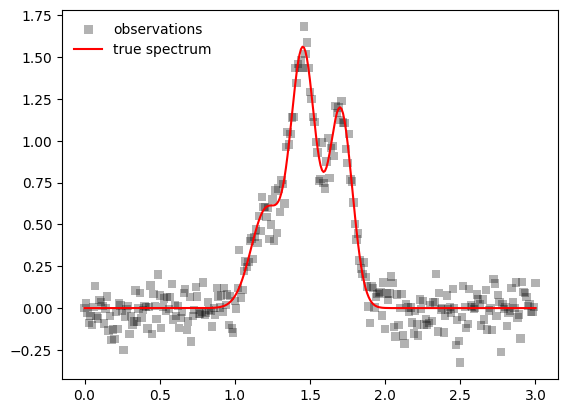

In [2]:
x, y_noisy, y_true = make_paper_like_synthetic_data(n_points=301, sigma2=0.01)

plt.scatter(
    x, y_noisy, marker="s", color="black", alpha=0.3, ec="none", label="observations"
)
plt.plot(x, y_true, linewidth=1.5, color="red", label="true spectrum")
plt.legend(frameon=False, loc="upper left")
plt.show()

In [3]:
class PsuedoVoigt:
    name = "PsuedoVoigt"
    n_parameters_per_basis = 3

    def evaluate(self, x, params):
        μ, σ, α = params
        x = x[None, :]
        μ = μ[:, None]
        σ = σ[:, None]
        α = α[:, None]
        σg = σ / np.sqrt(2 * np.log(2))

        lterm = (
            (1 - α)
            / (σg * np.sqrt(2 * np.pi))
            * np.exp(-1 * (x - μ) ** 2 / (2 * σg**2))
        )
        rterm = α / np.pi * σ / ((x - μ) ** 2 + σ**2)
        return lterm + rterm

In [4]:
class Parameterization:
    def __init__(self, K):
        self.K = K
        self.ndim = 4

    def pack(self, structured):
        a, μ, σ, α = structured
        return np.concatenate([a, μ, σ, α])

    def unpack(self, θ):
        return (
            θ[..., : self.K],
            θ[..., self.K : 2 * self.K],
            θ[..., self.K * 2 : 3 * self.K],
            θ[..., self.K * 3 :],
        )

    def validate(self, theta) -> None:
        if theta.size != self.ndim:
            raise ValueError(f"Expected {self.ndim} parameters, got {theta.size}")


class Prior:
    def __init__(self, amplitudes, center, width, mixing):
        self.amplitudes = amplitudes
        self.center = center
        self.width = width
        self.mixing = mixing

    def sample(self, rng, parameterization):
        K = parameterization.K
        a = self.amplitudes.sample(rng, size=K)
        μ = self.center.sample(rng, size=K)
        σ = self.width.sample(rng, size=K)
        α = self.mixing.sample(rng, size=K)
        return parameterization.pack((a, μ, σ, α))

    def log_prob(self, θ, parameterization):
        a, μ, σ, α = parameterization.unpack(θ)
        lp_a = np.sum(self.amplitudes.log_prob(a))
        lp_μ = np.sum(self.center.log_prob(μ))
        lp_σ = np.sum(self.width.log_prob(σ))
        lp_α = np.sum(self.mixing.log_prob(α))
        return float(lp_a + lp_μ + lp_σ + lp_α)


class UniformPrior:
    def __init__(self, lower, upper):
        self.lower = lower
        self.upper = upper

    def sample(self, rng, size=None):
        return rng.uniform(low=self.lower, high=self.upper, size=size)

    def log_prob(self, x):
        return np.where(
            (x < self.upper) & (x >= self.lower),
            np.log(1 / (self.upper - self.lower)),
            -np.inf,
        )

In [33]:
prior = Prior(
    GammaPrior(shape=0.8, rate=4),
    NormalPrior(mean=1.5, precision=10),
    GammaPrior(shape=0.3, rate=1.5),
    UniformPrior(lower=0.0, upper=1.0),
)

K = 4

model = SpectralModel(
    x=x,
    y=y_noisy,
    basis=PsuedoVoigt(),
    # basis=GaussianBasis(),
    prior=prior,
    likelihood=GaussianNoise(sigma2=0.01),
    parameterization=Parameterization(K=K),
)

In [34]:
from functools import partial

betas = beta_schedule(24)

sampler = ParallelTempering(
    model=model,
    betas=betas,
    rng=np.random.default_rng(42),
    kernel_factory=partial(
        metropolis_kernel_factory, proposal_scales=np.array([0.02, 0.02, 0.02, 0.02])
    ),
)

In [35]:
%%time
result = sampler.run(burn_in=10_000, samples=20_000, swap_every=1)

/home/jeroensangers/Virtual-environments/SSA/lib/python3.11/site-packages/bayspecdec/priors.py:29: RuntimeWarning: invalid value encountered in log
  out = self.shape * np.log(self.rate) - lgamma(self.shape) + (self.shape - 1.0) * np.log(x) - self.rate * x


CPU times: user 1min 14s, sys: 57 ms, total: 1min 14s
Wall time: 1min 14s


In [36]:
evidence = estimate_evidence(model, result)
print(f"Log Evidence (Z) for K={K}: {evidence.log_z:.2f}")

Log Evidence (Z) for K=4: -172.38


In [37]:
cold_samples = result.samples_by_temperature[-1]
a, μ, σ, α = model.parameterization.unpack(cold_samples)

sorting_key = np.argsort(μ, axis=1)
a = np.take_along_axis(a, axis=1, indices=sorting_key)
μ = np.take_along_axis(μ, axis=1, indices=sorting_key)
σ = np.take_along_axis(σ, axis=1, indices=sorting_key)
α = np.take_along_axis(α, axis=1, indices=sorting_key)

Text(0.5, 1.0, 'mixing')

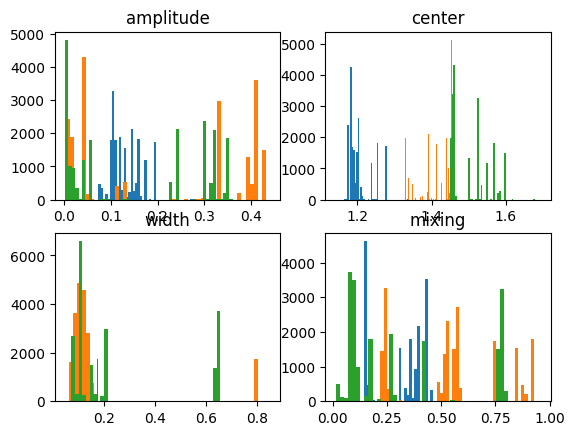

In [38]:
fig, axes = plt.subplots(nrows=2, ncols=2)

[[tl, tr], [bl, br]] = axes

for i in range(3):
    tl.hist(a[..., i], bins=50)
    tr.hist(μ[..., i], bins=50)
    bl.hist(σ[..., i], bins=50)
    br.hist(α[..., i], bins=50)
tl.set_title("amplitude")
tr.set_title("center")
bl.set_title("width")
br.set_title("mixing")

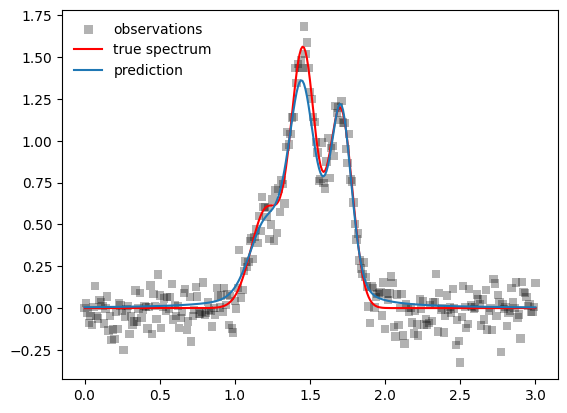

In [43]:
plt.scatter(
    x, y_noisy, marker="s", color="black", alpha=0.3, ec="none", label="observations"
)
plt.plot(x, y_true, linewidth=1.5, color="red", label="true spectrum")
plt.plot(
    x,
    np.sum(
        np.median(a, axis=0)[..., None]
        * PsuedoVoigt().evaluate(
            x, params=(np.median(μ, axis=0), np.median(σ, axis=0), np.median(α, axis=0))
        ),
        axis=0,
    ),
    label="prediction",
)
plt.legend(frameon=False, loc="upper left")
plt.show()